In [1]:
import os
import sys

# Проверяем, запущен ли ноутбук в среде Google Colab
if "google.colab" in sys.modules:
    !pip install uv -q
    !wget https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_2/pyproject.toml -q
    !uv pip install -r pyproject.toml --system -q
    os.kill(os.getpid(), 9)  # force runtime restart

# Семинар 1 · Ноутбук 3
# Интервалы прогнозирования и оценка их качества

Точечный прогноз $\hat y_{n+h|n}$ — это, как правило, **среднее** условного распределения
$y_{n+h}\mid y_1,\dots,y_n$. Но одно число не говорит, насколько мы уверены. **Интервал
прогноза** (prediction interval, PI) задаёт диапазон, в котором будущее значение окажется
с заданной вероятностью.

Лекция подчёркивает: *точечные прогнозы часто бесполезны без интервалов*. В этом ноутбуке мы:

- разберём PI **в предположении нормальности** остатков: $\hat y \pm z_{1-\alpha/2}\,\hat\sigma_h$;
- **выведем** аналитические формулы дисперсии для четырёх базовых методов — явно перечислим
  предположения, из которых они следуют, разберём вывод для naive и drift по шагам и проверим
  результат симуляцией;
- научимся **оценивать качество** интервальных прогнозов: Coverage Rate, Mean Interval Width,
  Winkler Score, Quantile Score (pinball loss) и CRPS — с разбором, откуда берутся квантильные
  метрики и почему именно они измеряют качество интервала;
- построим PI **из коробки** и посчитаем те же метрики для **всех четырёх методов** в трёх
  фреймворках — `statsforecast`, `sktime` и `etna` — и разберём, как именно каждый из них считает
  границы внутри.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

plt.rcParams["figure.figsize"] = (14, 5)

---
# 0. Данные и постановка задачи

## 0.1. Загрузка ряда и train/test-разбиение

Берём тот же ряд, что и в ноутбуке 1: квартальная прибыль на акцию J&J. Как и там, округляем
даты до начала квартала — иначе фреймворки в разделе 3 будут строить свою регулярную сетку дат
и молча потеряют точки при склейке с фактическими значениями (подробности — в ноутбуке 1, §0.1).

In [3]:
df = pd.read_csv(
    "https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_2/data/jj.csv"
)
df["date"] = pd.to_datetime(df["date"]).dt.to_period("Q").dt.start_time
df.head()

,date,data
0,1960-01-01,0.71
1,1960-04-01,0.63
2,1960-07-01,0.85
3,1960-10-01,0.44
4,1961-01-01,0.61


В ноутбуке 1 для точечных прогнозов хватало теста из 4 кварталов. Для интервалов этого мало:
**Coverage Rate** — это доля точек, попавших в интервал, и на 4 наблюдениях она может принимать
только значения $0\%, 25\%, 50\%, 75\%, 100\%$ — шаг слишком грубый, чтобы отличить хороший
интервал от плохого. Возьмём тест побольше — **8 кварталов (2 года)**.

train: 76 наблюдений (1960-01…1978-10)
test:  8 наблюдений (1979-01…1980-10)


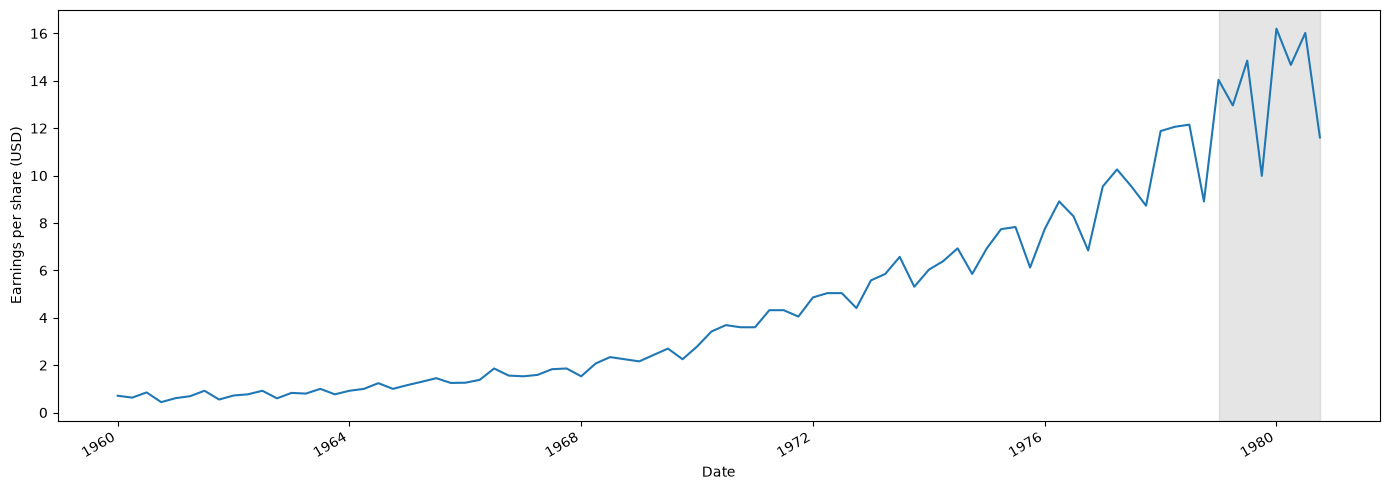

In [4]:
train = df.iloc[:-8].copy()
test = df.iloc[-8:].copy()
y = train["data"].values.astype(float)
n = len(y)

print(f"train: {len(train)} наблюдений ({train['date'].min():%Y-%m}…{train['date'].max():%Y-%m})")
print(f"test:  {len(test)} наблюдений ({test['date'].min():%Y-%m}…{test['date'].max():%Y-%m})")

fig, ax = plt.subplots()
ax.plot(df["date"], df["data"])
ax.set_xlabel("Date")
ax.set_ylabel("Earnings per share (USD)")
ax.axvspan(test["date"].iloc[0], test["date"].iloc[-1], color="#808080", alpha=0.2)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 0.2. Функция для графика с интервалом

Во всех разделах ниже нам нужен один и тот же график: история, точечный прогноз и закрашенная
полоса (или две — 80% и 95%) вокруг него. Как и в ноутбуке 1, выносим это в функцию, чтобы не
копировать код для каждого метода и каждого фреймворка.

In [5]:
def plot_forecast_pi(train, test, point, lo, hi, title, lo2=None, hi2=None):
    fig, ax = plt.subplots()
    ax.plot(train["date"], train["data"], "g-.", label="Train")
    ax.plot(test["date"], test["data"], "b-", label="Test")
    ax.plot(test["date"], point, "r--o", ms=4, label="Прогноз")
    if lo2 is not None:
        ax.fill_between(test["date"], lo2, hi2, color="r", alpha=0.15, label="80%")
    ax.fill_between(test["date"], lo, hi, color="r", alpha=0.30, label="95%")
    ax.set_xlabel("Date")
    ax.set_ylabel("Earnings per share (USD)")
    ax.legend(loc=2)
    ax.set_title(title)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

---
# 1. Интервал прогноза в предположении нормальности

Если ошибки прогноза распределены нормально, то $100(1-\alpha)\%$ интервал имеет вид

$$
\hat y_{n+h|n} \pm z_{1-\alpha/2}\,\hat\sigma_h,
$$

где $\hat\sigma_h$ — стандартное отклонение прогноза на $h$ шагов, а $z_{1-\alpha/2}$ — квантиль
стандартного нормального распределения.

In [6]:
for lvl in [80, 90, 95, 99]:
    alpha_lvl = 1 - lvl / 100
    z_lvl = stats.norm.ppf(1 - alpha_lvl / 2)
    print(f"level={lvl:>3}%   z = {z_lvl:.3f}")

level= 80%   z = 1.282
level= 90%   z = 1.645
level= 95%   z = 1.960
level= 99%   z = 2.576


## 1.1. Оценка $\hat\sigma$ по остаткам одношагового прогноза

При $h=1$ величину $\hat\sigma_1$ оценивают прямо по **остаткам** одношагового прогноза:
$\hat\sigma^2 = \frac{1}{n-K}\sum_{t} e_t^2$, где $K$ — число параметров, оценённых моделью
(для naive и seasonal naive $K=0$, для drift $K=1$ — угол наклона). Возьмём наивный прогноз
$\hat y_{t|t-1}=y_{t-1}$, тогда остатки — это первые разности $e_t = y_t - y_{t-1}$.

n = 76,  σ̂ (по остаткам naive) = 0.825


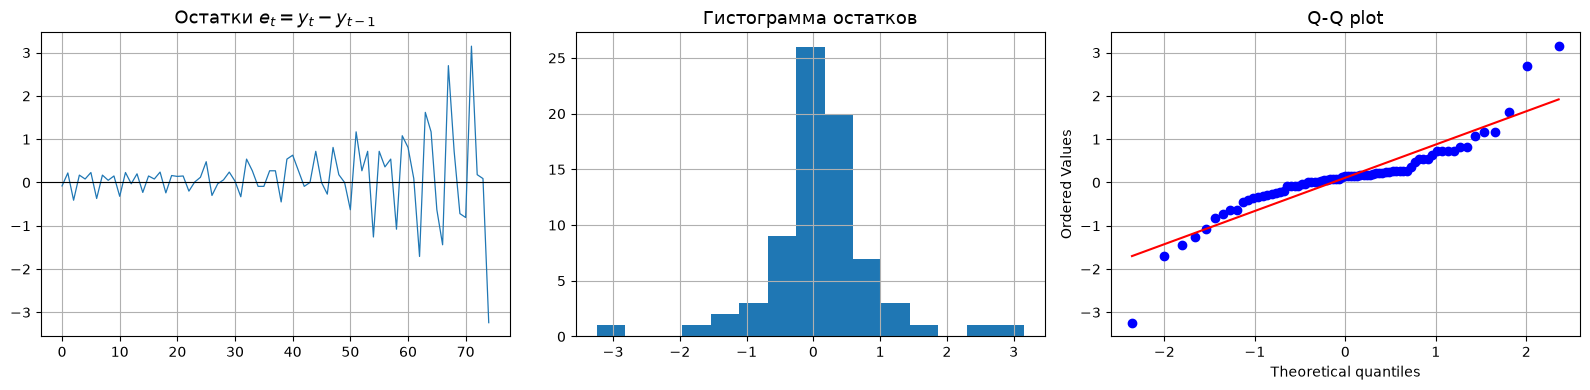

In [7]:
resid = y[1:] - y[:-1]  # остатки наивного прогноза
sigma_hat = np.sqrt(np.mean(resid**2))  # σ̂ = sqrt( mean(e_t²) ),  K=0 для naive
print(f"n = {n},  σ̂ (по остаткам naive) = {sigma_hat:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(resid, lw=0.9)
axes[0].axhline(0, color="k", lw=0.8)
axes[0].set_title("Остатки $e_t=y_t-y_{t-1}$", fontsize=13)
axes[0].grid()
axes[1].hist(resid, bins=15)
axes[1].set_title("Гистограмма остатков", fontsize=13)
axes[1].grid()
stats.probplot(resid, plot=axes[2])
axes[2].set_title("Q-Q plot", fontsize=13)
axes[2].grid()
plt.tight_layout()
plt.show()

🔍 На Q-Q plot видно, что точки на краях отклоняются от прямой — остатки не идеально нормальны.
У ряда J&J дисперсия квартальной прибыли растёт вместе с уровнем ряда (типичная картина для
растущих показателей компании), из-за чего остатки скошены и разброс неоднороден во времени.
Это ровно то, что лечится **преобразованием таргета** (ноутбук 2, Box–Cox/log): на
преобразованном ряде интервал в предположении нормальности работает честнее. Сейчас же мы
намеренно строим интервал «как есть», чтобы увидеть формулы и API — а к качеству вернёмся
в разделе 3, когда будем измерять Coverage Rate на тесте.

## 1.2. Наивный прогноз с интервалом

Для наивного метода дисперсия прогноза растёт линейно с горизонтом (вывод — в разделе 2):
$\hat\sigma_h = \hat\sigma\sqrt{h}$. Построим прогноз на 8 кварталов вперёд с 95%-м интервалом
«руками».

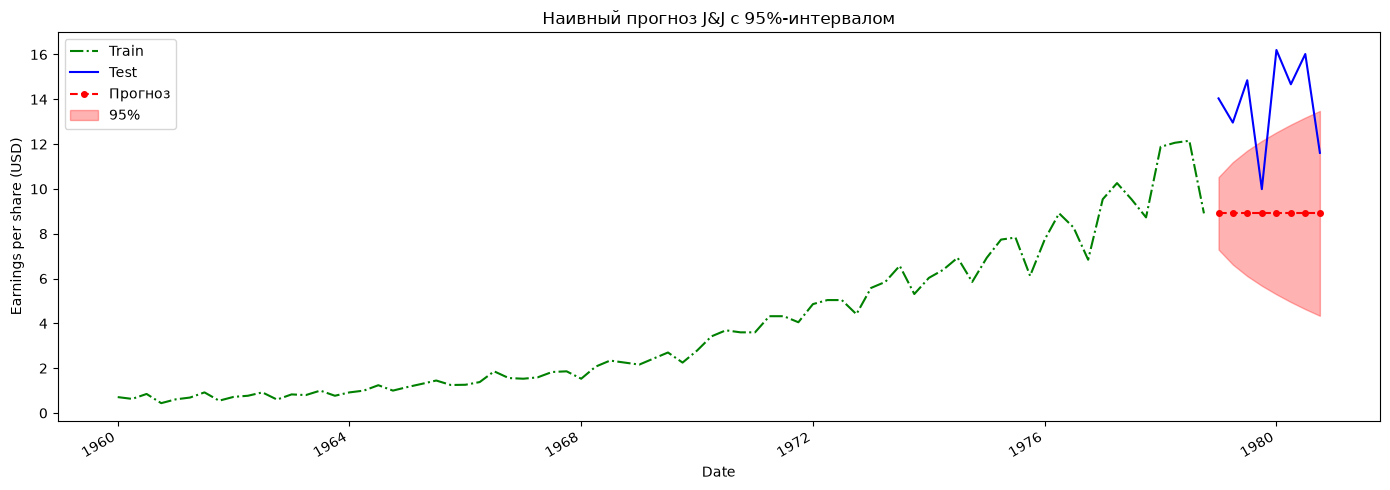

,h,прогноз,Lo 95,Hi 95
0,1,8.91,7.29,10.53
1,2,8.91,6.62,11.20
2,3,8.91,6.11,11.71
3,4,8.91,5.68,12.14
4,5,8.91,5.30,12.52
5,6,8.91,4.95,12.87
6,7,8.91,4.63,13.19
7,8,8.91,4.34,13.48


In [8]:
h = 8
hh = np.arange(1, h + 1)
z95 = stats.norm.ppf(0.975)

point_naive = np.full(h, y[-1])  # наивный прогноз: последнее значение
sigma_h_naive_vals = sigma_hat * np.sqrt(hh)  # σ_h = σ̂·√h
lo = point_naive - z95 * sigma_h_naive_vals
hi = point_naive + z95 * sigma_h_naive_vals

plot_forecast_pi(train, test, point_naive, lo, hi, "Наивный прогноз J&J с 95%-интервалом")

pd.DataFrame({"h": hh, "прогноз": point_naive.round(2), "Lo 95": lo.round(2), "Hi 95": hi.round(2)})

Интервал **расширяется** по мере роста горизонта — чем дальше в будущее, тем больше
неопределённость. Это фундаментальное свойство многошаговых прогнозов.

🔍 **Важная оговорка на будущее.** Эта формула учитывает только дисперсию остатков одношагового
прогноза. Она **не** учитывает неопределённость в оценке параметров модели и тем более
неопределённость в выборе самой модели (а вдруг наивный метод — не лучший?). Поэтому на практике
реальные интервалы почти всегда оказываются **шире**, чем говорит формула — а построенные по ней
интервалы систематически слишком узкие. Единственный способ это проверить — сравнить с фактическим
покрытием на отложенных данных (раздел 3).

---
# 2. Аналитические формулы для четырёх базовых методов

## 2.0. Из каких предположений выводятся формулы

Прежде чем выписывать формулы, зафиксируем модель мира, внутри которой они верны. Каждый базовый
метод неявно предполагает, что ряд порождается так:

$$
y_t = \underbrace{\mu_t}_{\text{«сигнал», который метод и оценивает}} + \varepsilon_t,
$$

а про шум $\varepsilon_t$ делаются **четыре предположения**:

1. **Несмещённость:** $\mathbb E[\varepsilon_t]=0$ — метод в среднем не промахивается
   (иначе интервал нужно было бы сдвигать, а не только расширять).
2. **Некоррелированность:** $\mathrm{Cov}(\varepsilon_t,\varepsilon_s)=0$ при $t\ne s$ — это
   ключевое допущение, именно оно позволяет складывать дисперсии будущих ошибок. Проверяется по
   ACF остатков: если в остатках осталась автокорреляция, интервал будет неправильным.
3. **Гомоскедастичность:** $\mathrm{Var}(\varepsilon_t)=\sigma^2$ одинакова во времени — иначе
   одна оценка $\hat\sigma$ на весь ряд не имеет смысла (лечится преобразованием таргета,
   ноутбук 2).
4. **Нормальность:** $\varepsilon_t\sim\mathcal N(0,\sigma^2)$ — нужна только на последнем шаге,
   чтобы перевести дисперсию в границы через квантиль $z_{1-\alpha/2}$. Первые три дают
   $\sigma_h$, четвёртое — форму интервала.

Плюс ещё два допущения, о которых обычно молчат:

5. **Параметры модели известны точно.** У mean, naive и seasonal naive параметров нет вовсе, а
   у drift наклон оценивается — и там мы этот источник неопределённости учтём явно (см. ниже),
   что и делает формулу drift «толще» остальных.
6. **Модель выбрана правильно.** Неопределённость «а вдруг метод не тот» не учитывается никак —
   из-за этого реальные интервалы шире формульных (об этом уже говорили в §1.2).

### Разбор вывода: naive

Наивный метод — это модель случайного блуждания $y_t = y_{t-1} + \varepsilon_t$. Разворачиваем
её на $h$ шагов вперёд от момента $n$:

$$
\begin{aligned}
y_{n+1} &= y_n + \varepsilon_{n+1},\\
y_{n+2} &= y_{n+1} + \varepsilon_{n+2} = y_n + \varepsilon_{n+1} + \varepsilon_{n+2},\\
&\;\;\vdots\\
y_{n+h} &= y_n + \sum_{j=1}^{h}\varepsilon_{n+j}.
\end{aligned}
$$

Прогноз — это условное среднее: $\hat y_{n+h|n}=\mathbb E[y_{n+h}\mid y_1..y_n]=y_n$
(по предположению 1 все будущие $\varepsilon$ в среднем нулевые). Значит **ошибка прогноза**
равна ровно сумме будущих шоков:

$$
e_{n+h} = y_{n+h}-\hat y_{n+h|n} = \sum_{j=1}^{h}\varepsilon_{n+j}.
$$

Дисперсия суммы **некоррелированных** (предположение 2) слагаемых равна сумме дисперсий, а все
они равны $\sigma^2$ (предположение 3):

$$
\sigma_h^2 = \mathrm{Var}\Big(\sum_{j=1}^{h}\varepsilon_{n+j}\Big)
= \sum_{j=1}^{h}\mathrm{Var}(\varepsilon_{n+j}) = h\sigma^2
\quad\Longrightarrow\quad \sigma_h = \sigma\sqrt h .
$$

Наконец, по предположению 4 сумма нормальных величин нормальна, поэтому
$y_{n+h}\mid y_{1..n}\sim\mathcal N\big(y_n,\;h\sigma^2\big)$ — и интервал берётся как
$y_n \pm z_{1-\alpha/2}\,\sigma\sqrt h$. Видно, где какое предположение сработало: **2 и 3** дали
$h\sigma^2$, **4** — множитель $z$.

### Тот же приём для остальных трёх

- **Mean.** Здесь $\mu_t\equiv\mu$ и прогноз $\hat y_{n+h|n}=\bar y$. Ошибка складывается из двух
  независимых частей: будущего шока $\varepsilon_{n+h}$ (дисперсия $\sigma^2$) и ошибки оценки
  среднего $\bar y - \mu$ (дисперсия $\sigma^2/n$). Итого
  $\sigma_h^2=\sigma^2+\sigma^2/n=\sigma^2(1+\tfrac1n)$ — **не зависит от $h$**: между «через
  квартал» и «через 5 лет» модель не видит разницы.
- **Seasonal naive.** Модель $y_t=y_{t-m}+\varepsilon_t$: прогноз на $h$ шагов опирается на
  значение того же сезона, а до него надо «пройти» $k+1$ сезонных шагов, где
  $k=\lfloor (h-1)/m\rfloor$. Складываются $k+1$ шоков → $\sigma_h=\sigma\sqrt{k+1}$, отсюда
  характерные ступеньки.
- **Drift.** Модель $y_t=y_{t-1}+c+\varepsilon_t$, прогноз $\hat y_{n+h|n}=y_n+h\hat c$, где
  наклон оценён как $\hat c=\frac{y_n-y_1}{n-1}$. К сумме $h$ будущих шоков (как у naive)
  добавляется **ошибка оценки наклона**, помноженная на $h$: $h(\hat c - c)$. Сама $\hat c$ —
  это среднее $n-1$ первых разностей, поэтому $\mathrm{Var}(\hat c)=\sigma^2/(n-1)$, и
  $$
  \sigma_h^2 = \underbrace{h\sigma^2}_{\text{будущие шоки}}
  + \underbrace{h^2\frac{\sigma^2}{n-1}}_{\text{ошибка наклона}}
  = \sigma^2 h\Big(1+\frac{h}{n-1}\Big).
  $$
  Второе слагаемое растёт как $h^2$ — поэтому у drift интервал раздувается быстрее всех.

## 2.1. Сводка формул

Собираем результат (он же — FPP3, Table 5.2):

$$
\begin{aligned}
\textbf{Mean:}\quad & \hat\sigma_h = \hat\sigma\sqrt{1+\tfrac1n}\\
\textbf{Naive:}\quad & \hat\sigma_h = \hat\sigma\sqrt{h}\\
\textbf{Seasonal naive:}\quad & \hat\sigma_h = \hat\sigma\sqrt{k+1},\quad k=\Big\lfloor \tfrac{h-1}{m}\Big\rfloor\\
\textbf{Drift:}\quad & \hat\sigma_h = \hat\sigma\sqrt{h\Big(1+\tfrac{h}{n-1}\Big)}
\end{aligned}
$$

где $\hat\sigma^2=\frac1n\sum_{t=1}^{n}e_t^2$ — дисперсия остатков **одношагового** прогноза
соответствующего метода, $m$ — длина сезона. Множитель при $\hat\sigma$ и определяет, как быстро
расширяется интервал с горизонтом $h$.


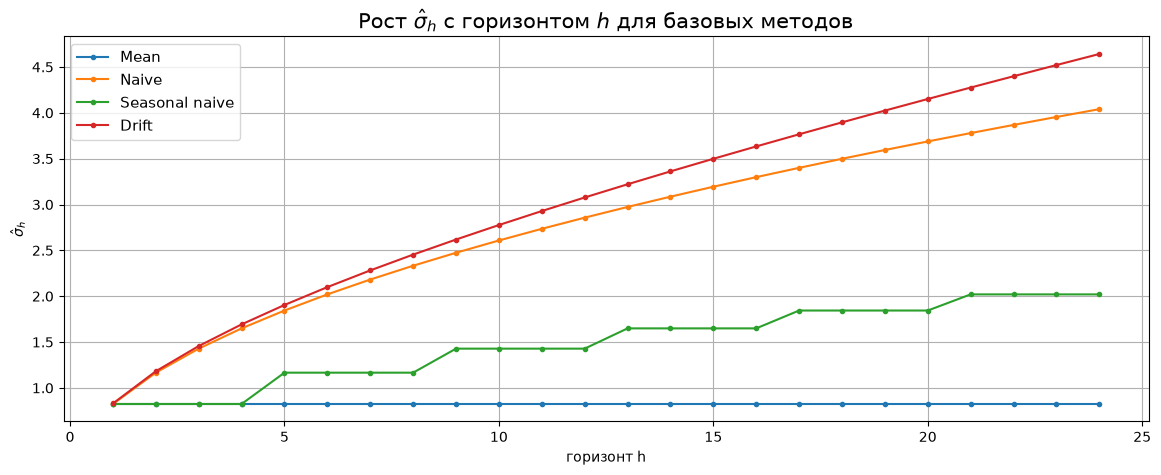

In [9]:
def sigma_h_mean(sigma, n, h, m=1):
    return sigma * np.sqrt(1 + 1 / n) * np.ones(h)


def sigma_h_naive(sigma, n, h, m=1):
    return sigma * np.sqrt(np.arange(1, h + 1))


def sigma_h_snaive(sigma, n, h, m):
    k = np.floor((np.arange(1, h + 1) - 1) / m)
    return sigma * np.sqrt(k + 1)


def sigma_h_drift(sigma, n, h, m=1):
    hh = np.arange(1, h + 1)
    return sigma * np.sqrt(hh * (1 + hh / (n - 1)))


H = 24
formulas = {
    "Mean": sigma_h_mean,
    "Naive": sigma_h_naive,
    "Seasonal naive": sigma_h_snaive,
    "Drift": sigma_h_drift,
}

fig, ax = plt.subplots()
for name, fn in formulas.items():
    ax.plot(np.arange(1, H + 1), fn(sigma_hat, n, H, 4), "-o", ms=3, label=name)
ax.set_title(r"Рост $\hat\sigma_h$ с горизонтом $h$ для базовых методов", fontsize=15)
ax.set_xlabel("горизонт h")
ax.set_ylabel(r"$\hat\sigma_h$")
ax.legend(fontsize=11)
ax.grid()
plt.show()

- У **Mean** дисперсия не растёт — прогноз опирается на всю выборку и её среднее уже
довольно точно оценено.
- У **Seasonal naive** рост идёт ступеньками: внутри одного сезонного
цикла $\hat\sigma_h$ не меняется, а на границе цикла подскакивает.
- У **Naive** рост $\propto\sqrt h$
— интуиция простая: наивный $h$-шаговый прогноз равен $y_n$ плюс сумма $h$ будущих
(гипотетически независимых) одношаговых ошибок, а дисперсия суммы независимых слагаемых
складывается: $\mathrm{Var}=h\hat\sigma^2$.
- У **Drift** — быстрее всех, потому что к той же
сумме ошибок добавляется неопределённость в оценке наклона $\frac{y_n-y_1}{n-1}$, которая с
ростом $h$ входит в прогноз со всё большим весом.

## 2.2. Проверка вывода симуляцией

Вывод выше — это цепочка из предположений, и её стоит проверить численно. Сгенерируем много
траекторий случайного блуждания с **известной** $\sigma$, посчитаем эмпирическое стандартное
отклонение ошибки наивного прогноза на каждом горизонте и сравним с $\sigma\sqrt h$. Заодно
проверим drift — там, где к шокам добавляется ошибка оценки наклона.

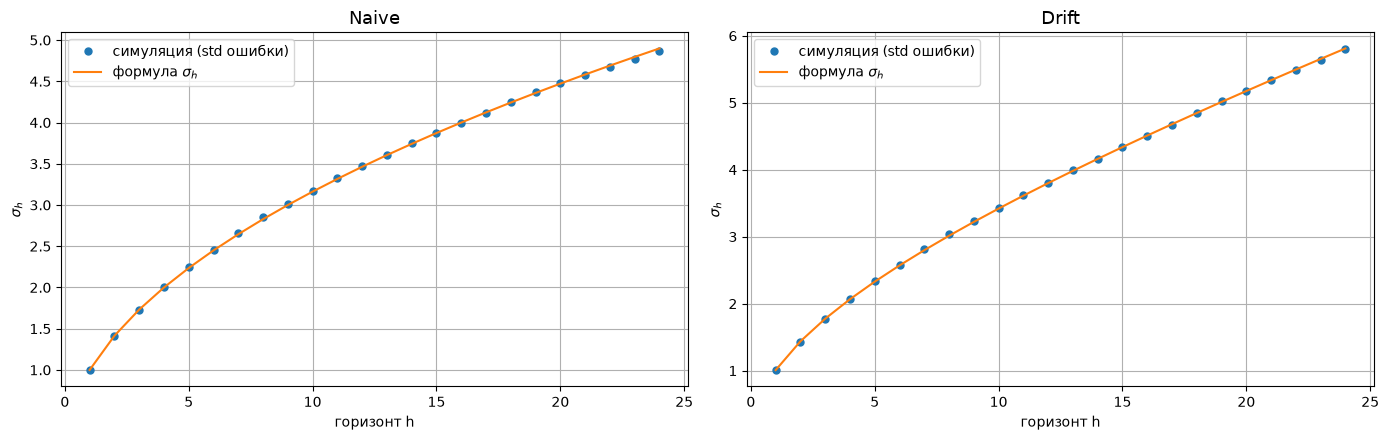

In [10]:
rng = np.random.default_rng(42)
n_sim, n_obs, sigma_true = 20_000, 60, 1.0

eps = rng.normal(0, sigma_true, size=(n_sim, n_obs + H))
paths = np.cumsum(eps, axis=1)  # случайное блуждание y_t = y_{t-1} + eps_t

y_last = paths[:, n_obs - 1]
future = paths[:, n_obs:]  # истинные будущие значения

err_naive = future - y_last[:, None]  # ошибка наивного прогноза
slope_hat = (paths[:, n_obs - 1] - paths[:, 0]) / (n_obs - 1)
err_drift = future - (y_last[:, None] + np.arange(1, H + 1) * slope_hat[:, None])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, err, fn, name in [
    (axes[0], err_naive, sigma_h_naive, "Naive"),
    (axes[1], err_drift, sigma_h_drift, "Drift"),
]:
    ax.plot(np.arange(1, H + 1), err.std(axis=0), "o", ms=5, label="симуляция (std ошибки)")
    ax.plot(np.arange(1, H + 1), fn(sigma_true, n_obs, H), "-", label="формула $\\sigma_h$")
    ax.set_title(name, fontsize=13)
    ax.set_xlabel("горизонт h")
    ax.set_ylabel(r"$\sigma_h$")
    ax.legend()
    ax.grid()
plt.tight_layout()
plt.show()

🔍 Точки ложатся на линию — формулы воспроизводятся симуляцией в точности. Это и есть смысл
вывода: мы не «подобрали» множители $\sqrt h$ и $\sqrt{h(1+h/(n-1))}$, а получили их из
предположений 1–3. Обратите внимание: в симуляции предположения выполнены **по построению**
(мы сами генерировали независимый гомоскедастичный нормальный шум). На реальном ряде J&J это не
так — именно поэтому дальше мы будем измерять фактическое покрытие на тесте.

## 2.3. Полный ручной интервал для всех четырёх методов

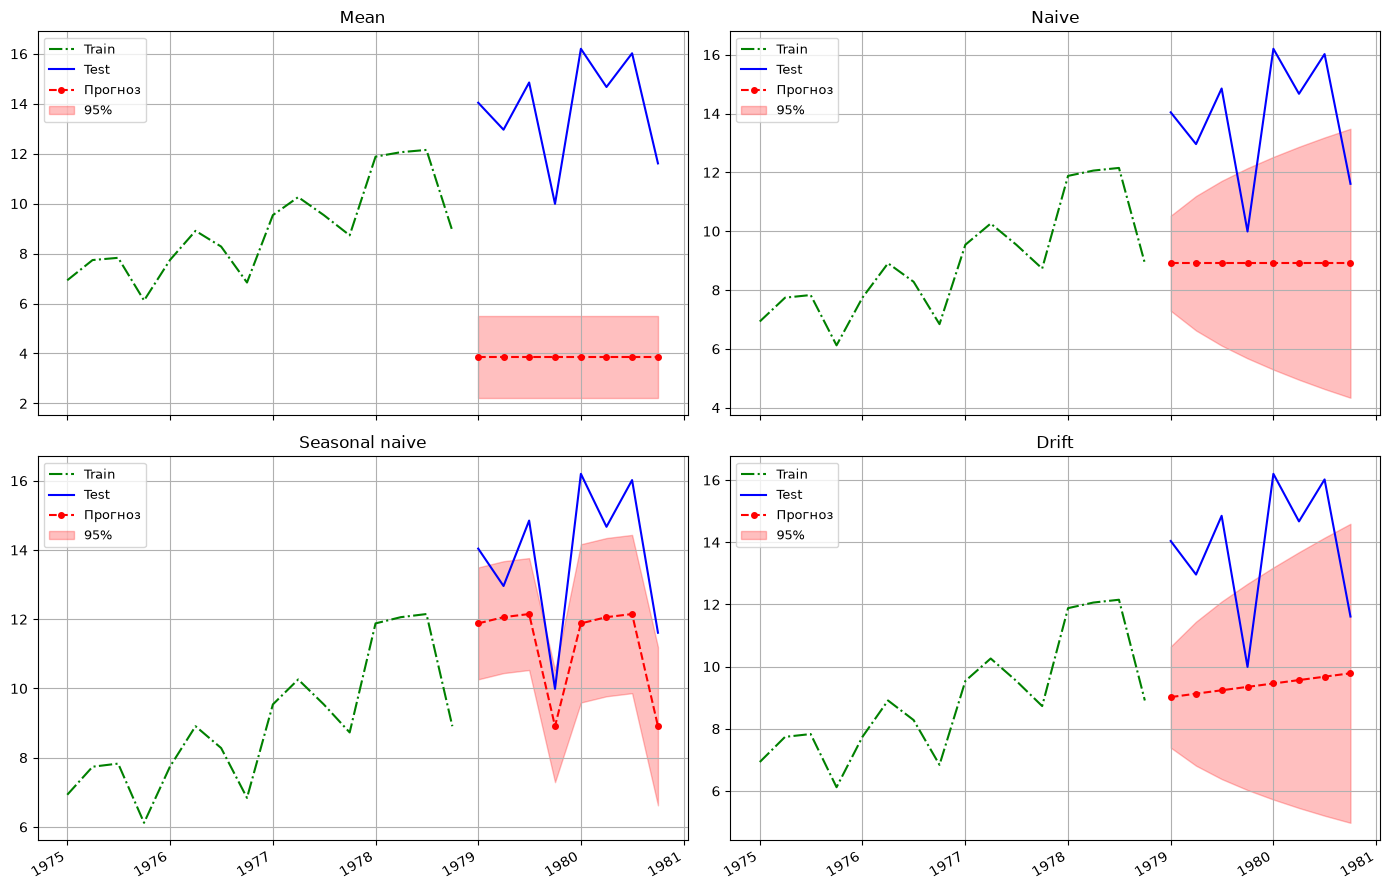

In [11]:
last, first = y[-1], y[0]
m = 4  # длина сезона у квартального ряда

point_mean = np.full(h, y.mean())
point_snaive = np.array([y[-m + (hi_ - 1) % m] for hi_ in hh])
slope = (last - first) / (n - 1)
point_drift = last + hh * slope

points = {
    "Mean": point_mean,
    "Naive": point_naive,
    "Seasonal naive": point_snaive,
    "Drift": point_drift,
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
for ax, (name, fn) in zip(axes.ravel(), formulas.items()):
    sig_h = fn(sigma_hat, n, h, m)
    pt = points[name]
    lo_m, hi_m = pt - z95 * sig_h, pt + z95 * sig_h
    ax.plot(train["date"].iloc[-16:], train["data"].iloc[-16:], "g-.", label="Train")
    ax.plot(test["date"], test["data"], "b-", label="Test")
    ax.plot(test["date"], pt, "r--o", ms=4, label="Прогноз")
    ax.fill_between(test["date"], lo_m, hi_m, color="r", alpha=0.25, label="95%")
    ax.set_title(name)
    ax.legend(fontsize=9)
    ax.grid()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

---
# 3. Метрики качества интервального прогноза: формулы руками

Точечные метрики (RMSE, MAE, …) не годятся для интервалов — нужны специальные меры. Разберём
пять, реализовав каждую «руками» на **тестовой** части ряда, а затем в разделе 4 посчитаем те же
числа через фреймворки и сверим.

In [12]:
y_true = test["data"].values.astype(float)
alpha = 0.05

# нормальный 95%-интервал наивного прогноза на тест (те же формулы, что в разделе 1-2)
sigma_h_test = sigma_hat * np.sqrt(hh)
L = point_naive - z95 * sigma_h_test  # нижняя граница
U = point_naive + z95 * sigma_h_test  # верхняя граница

## 3.1. Coverage Rate (CR) и Mean Interval Width (MIW)

$$
\mathrm{CR}=\frac1n\sum_t \mathbb{I}\{y_t\in[\ell_{\alpha,t},u_{\alpha,t}]\},
\qquad
\mathrm{MIW}=\frac1n\sum_t (u_{\alpha,t}-\ell_{\alpha,t}).
$$

- **CR** — доля фактических значений, попавших в интервал (в идеале $\approx 1-\alpha$).
- **MIW** — средняя ширина.

Ни одна из них не работает в одиночку: тривиально расширив интервал до
$\pm\infty$, получим CR = 100%, но толку в таком прогнозе нет — поэтому обе метрики смотрят
вместе, как компромисс «покрытие ↔ ширина».

🔍 При равенстве покрытий лучшими считаются интервалы с меньшей шириной

In [13]:
def coverage_rate(y, lo, hi):
    return np.mean((y >= lo) & (y <= hi))


def mean_interval_width(lo, hi):
    return np.mean(hi - lo)


print(
    f"Coverage Rate (цель {1 - alpha:.0%}): {coverage_rate(y_true, L, U):.1%}"
)  # Так себе покрытие, выше обсуждали почему
print(f"Mean Interval Width: {mean_interval_width(L, U):.2f}")

Coverage Rate (цель 95%): 25.0%
Mean Interval Width: 6.59


## 3.2. Winkler Score

Winkler Score объединяет ширину и штраф за «промахи» мимо интервала $100(1-\alpha)\%$:

$$
W_t=
\begin{cases}
(u_{\alpha,t}-\ell_{\alpha,t}) + \dfrac{2}{\alpha}(\ell_{\alpha,t}-y_t), & y_t<\ell_{\alpha,t},\\[6pt]
(u_{\alpha,t}-\ell_{\alpha,t}), & \ell_{\alpha,t}\le y_t\le u_{\alpha,t},\\[6pt]
(u_{\alpha,t}-\ell_{\alpha,t}) + \dfrac{2}{\alpha}(y_t-u_{\alpha,t}), & y_t>u_{\alpha,t}.
\end{cases}
$$

Если наблюдение внутри интервала — штраф равен просто ширине. Если снаружи — добавляется штраф,
пропорциональный тому, насколько далеко значение вышло за границу. **Меньше — лучше.**

In [14]:
def winkler_score(y, lo, hi, alpha):
    width = hi - lo
    below, above = y < lo, y > hi
    w = width.copy().astype(float)
    w[below] += (2 / alpha) * (lo[below] - y[below])
    w[above] += (2 / alpha) * (y[above] - hi[above])
    return np.mean(w)


print(f"Winkler Score (95%): {winkler_score(y_true, L, U, alpha):.2f}")

Winkler Score (95%): 90.24


## 3.3. Quantile Score (pinball loss)

### Откуда берётся

Coverage и Winkler оценивают интервал **целиком**, но интервал — это просто пара квантилей
($p=0.025$ и $p=0.975$ для 95%), и логично уметь оценивать **каждую границу отдельно**.
Задача «предскажи квантиль уровня $p$» — это отдельная задача оценивания, и у неё есть своя
естественная функция потерь.

Вспомним, откуда берутся привычные точечные метрики. Каждая из них — это функция потерь,
**минимум которой достигается на нужной характеристике распределения**:

| функция потерь | что минимизирует | оптимальный прогноз |
|---|---|---|
| $(y-f)^2$ | MSE | **среднее** распределения |
| $\lvert y-f\rvert$ | MAE | **медиана** (= квантиль $p=0.5$) |
| асимметричный модуль | Quantile Score | **квантиль уровня $p$** |

Идея последней строки: MAE штрафует недолёт и перелёт одинаково, поэтому её минимум —
посередине (медиана). Чтобы минимум уехал в квантиль $p=0.975$, нужно сделать штраф
**асимметричным**: сильно наказывать за то, что прогноз оказался *ниже* факта, и почти не
наказывать за то, что он *выше*. Именно это и делает Quantile Score:

$$
Q_{p,t}=
\begin{cases}
2(1-p)\,(f_{p,t}-y_t), & y_t<f_{p,t} \quad\text{(прогноз завышен — вес } 1-p),\\[4pt]
2p\,(y_t-f_{p,t}), & y_t\ge f_{p,t} \quad\text{(прогноз занижен — вес } p).
\end{cases}
$$

Из-за формы графика (две прямые под разными углами, как отскок шарика в пинболе) её называют
**pinball loss**. Множитель 2 часто опускают.

### Почему это оценивает качество интервала

Подставим $p=0.975$ — верхняя граница. Вес занижения $2p = 1.95$, вес завышения $2(1-p)=0.05$:
**промах наружу штрафуется в 39 раз сильнее**, чем лишняя ширина. Метрика сама находит баланс
«покрытие ↔ ширина», который в §3.1 нам приходилось смотреть двумя числами: слишком узкая
граница часто ловит большой штраф за промахи, слишком широкая — постоянно платит маленький штраф
за завышение. Минимум достигается ровно тогда, когда граница — честный квантиль $0.975$
прогнозного распределения, то есть когда фактическое покрытие совпадает с заявленным.

Ключевое отличие от Winkler: Quantile Score оценивает **каждый квантиль по отдельности**,
поэтому её можно усреднить по произвольному набору уровней. Такое усреднение называют
**MQLoss** (Multi-Quantile Loss) — с ней мы встретимся в `utilsforecast`.

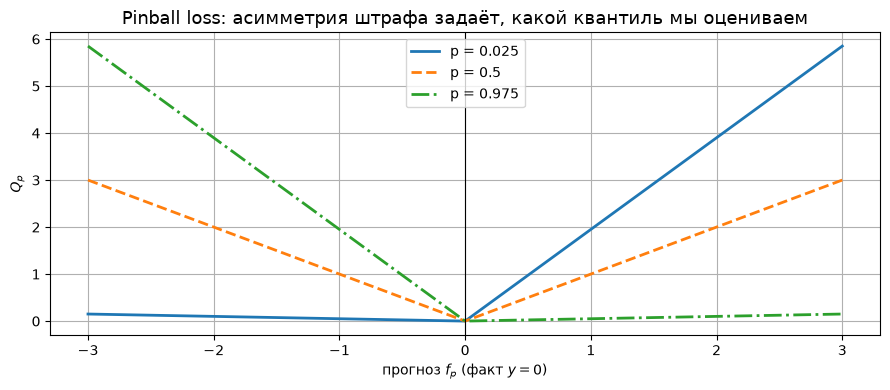

In [15]:
def quantile_score(y, f, p):
    diff = f - y
    return np.mean(np.where(y < f, 2 * (1 - p) * diff, 2 * p * (-diff)))


# как выглядит сама функция потерь для разных p
grid = np.linspace(-3, 3, 401)  # значение прогноза при факте y = 0
fig, ax = plt.subplots(figsize=(9, 4))
for p, style in [(0.025, "-"), (0.5, "--"), (0.975, "-.")]:
    loss = np.where(grid > 0, 2 * (1 - p) * grid, 2 * p * (-grid))
    ax.plot(grid, loss, style, lw=2, label=f"p = {p}")
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("прогноз $f_p$ (факт $y=0$)")
ax.set_ylabel("$Q_p$")
ax.set_title("Pinball loss: асимметрия штрафа задаёт, какой квантиль мы оцениваем", fontsize=13)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

🔍 При $p=0.5$ штраф симметричен — это ровно MAE (с точностью до множителя 2), и минимум
достигается на медиане. При $p=0.975$ левое плечо (прогноз ниже факта = граница пробита)
гораздо круче правого — модели выгодно держать границу высоко. При $p=0.025$ — зеркально.

Посчитаем метрику для наших границ:

In [16]:
qs_low = quantile_score(y_true, L, alpha / 2)  # p = 0.025
qs_high = quantile_score(y_true, U, 1 - alpha / 2)  # p = 0.975
print(f"Quantile Score, нижняя граница (p=0.025): {qs_low:.3f}")
print(f"Quantile Score, верхняя граница (p=0.975): {qs_high:.3f}")
print(f"среднее по двум границам (≈MQLoss):        {(qs_low + qs_high) / 2:.3f}")

Quantile Score, нижняя граница (p=0.025): 0.409
Quantile Score, верхняя граница (p=0.975): 4.103
среднее по двум границам (≈MQLoss):        2.256


## 3.4. CRPS

### Откуда берётся

Quantile Score оценивает один уровень $p$, MQLoss — несколько выбранных. Но выбор уровней
произволен: почему 0.025 и 0.975, а не 0.05/0.5/0.95? Логичный следующий шаг — **усреднить
квантильную оценку по всем уровням сразу**. Это и есть **CRPS** (Continuous Ranked Probability
Score):

$$
\mathrm{CRPS}(F_t, y_t) \;=\; \int_0^1 Q_{p,t}\big(F_t^{-1}(p),\,y_t\big)\,dp ,
$$

где $Q_p$ — pinball loss из §3.3 (с множителем 2), а $F_t^{-1}(p)$ — квантиль уровня $p$
прогнозного распределения. То есть **CRPS = pinball loss, усреднённая по бесконечно плотной
сетке квантилей** — оценивается уже не пара границ, а всё распределение целиком.

У той же величины есть вторая, эквивалентная форма — та, что обычно и пишут в учебниках:

$$
\mathrm{CRPS}=\frac1n\sum_t \int_{-\infty}^{\infty}\big(F_t(x)-\mathbb{I}\{x\ge y_t\}\big)^2\,dx .
$$

Её интуиция другая, но не менее наглядная: факт $y_t$ — это тоже распределение, только
вырожденное, его CDF — ступенька $\mathbb I\{x\ge y_t\}$. CRPS измеряет **площадь между
предсказанной CDF и этой ступенькой**. Идеальный прогноз (уверенное попадание в точку) даёт
площадь 0; размазанное распределение платит за неуверенность, смещённое — за смещение.

Два полезных свойства:

- CRPS измеряется **в единицах ряда** (здесь — в долларах на акцию), как MAE;
- если прогнозное распределение вырождено в точку (обычный точечный прогноз), CRPS в точности
  равен **MAE**. То есть CRPS — честное обобщение MAE на вероятностные прогнозы, и по нему можно
  сравнивать точечную модель с интервальной.

### При чём тут распределения у наивных моделей

Чтобы посчитать CRPS, нужна не пара границ, а **вся функция распределения** $F_t$. Откуда она
берётся у naive/mean/drift, которые выдают одно число? Из раздела 2: мы вывели там не просто
формулу ширины, а **полное условное распределение** прогноза

$$
y_{n+h}\mid y_{1..n}\;\sim\;\mathcal N\big(\hat y_{n+h|n},\;\sigma_h^2\big),
$$

где $\hat y_{n+h|n}$ — точечный прогноз метода, а $\sigma_h$ — его аналитическая формула
($\sigma\sqrt h$ для naive и т. д.). Границы интервала — это просто два квантиля этого
распределения, а CRPS использует его целиком. Поэтому:

- **интервал и CRPS у базовых моделей — не разные сущности, а два среза одного и того же
  нормального распределения**;
- если предположение нормальности нарушено, «плывут» *обе* метрики сразу;
- именно так и устроен `predict_proba` в `sktime` (§4.2) — он отдаёт этот самый объект
  $\mathcal N(\hat y_h,\sigma_h^2)$, а метрика `CRPS` из `sktime` считается уже по нему.

Для нормального $\mathcal N(\mu,\sigma)$ интеграл берётся аналитически:

$$
\mathrm{CRPS}=\sigma\left[\omega\,(2\Phi(\omega)-1)+2\varphi(\omega)-\tfrac{1}{\sqrt\pi}\right],
\qquad \omega=\frac{y-\mu}{\sigma}.
$$

In [17]:
def crps_gaussian(y, mu, sigma):
    omega = (y - mu) / sigma
    return np.mean(
        sigma
        * (omega * (2 * stats.norm.cdf(omega) - 1) + 2 * stats.norm.pdf(omega) - 1 / np.sqrt(np.pi))
    )


crps_norm = crps_gaussian(y_true, point_naive, sigma_h_test)
print(f"CRPS (нормальный прогноз): {crps_norm:.3f}")

CRPS (нормальный прогноз): 4.034


Проверим утверждение «CRPS = pinball loss, усреднённая по всем квантилям» численно: возьмём
плотную сетку уровней $p$, для каждого посчитаем соответствующий квантиль нормального прогноза
и усредним Quantile Score.

средняя pinball loss по сетке из 999 квантилей: 4.0374
CRPS по замкнутой формуле:                            4.0339


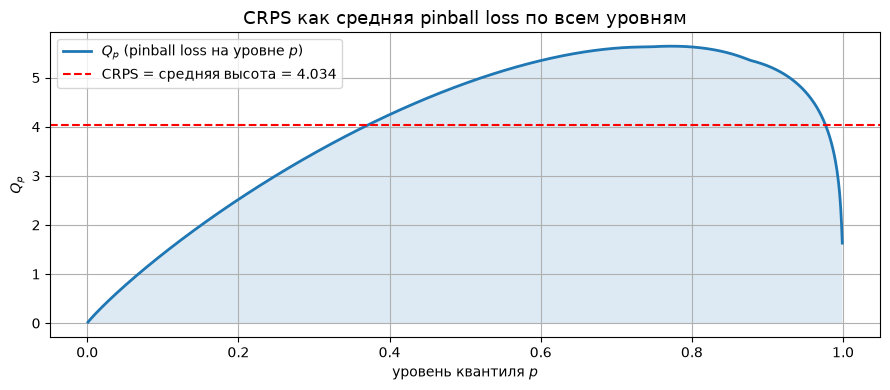

In [18]:
p_grid = np.linspace(0.001, 0.999, 999)
qs_grid = [
    quantile_score(y_true, point_naive + stats.norm.ppf(p) * sigma_h_test, p) for p in p_grid
]

print(f"средняя pinball loss по сетке из {len(p_grid)} квантилей: {np.mean(qs_grid):.4f}")
print(f"CRPS по замкнутой формуле:                            {crps_norm:.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(p_grid, qs_grid, lw=2, label="$Q_p$ (pinball loss на уровне $p$)")
ax.axhline(crps_norm, color="r", ls="--", label=f"CRPS = средняя высота = {crps_norm:.3f}")
ax.fill_between(p_grid, qs_grid, alpha=0.15)
ax.set_xlabel("уровень квантиля $p$")
ax.set_ylabel("$Q_p$")
ax.set_title("CRPS как средняя pinball loss по всем уровням", fontsize=13)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

🔍 Числа совпали (расхождение — дискретность сетки). Хорошо видно и другое: наибольший вклад в
CRPS дают **центральные** квантили, а хвосты вносят мало. Практическое следствие: CRPS в первую
очередь оценивает, насколько хорошо распределение «сидит» в целом, и сравнительно мягко реагирует
на неточность далёких хвостов — если вам важны именно 95%-границы, смотрите Winkler или Quantile
Score на нужных уровнях, а не только CRPS.

## 3.5. Итоговая таблица: метрика и её место во фреймворках

Мы реализовали пять мер руками. Прежде чем идти во фреймворки, сразу зафиксируем, что где
искать — дальше будем сверять именно с этими названиями.

| метрика | руками | `utilsforecast.losses` | `sktime.performance_metrics` | `etna.metrics` |
|---|---|---|---|---|
| Coverage | `coverage_rate` | `coverage` | `EmpiricalCoverage` | `Coverage` |
| Width | `mean_interval_width` | — | `IntervalWidth` | `Width` |
| Winkler | `winkler_score` | `winkler_score` (в следующем релизе) | — | — |
| Pinball / MQLoss | `quantile_score` | `quantile_loss`, `mqloss` | `PinballLoss` | — |
| CRPS | `crps_gaussian` | `scaled_crps` | `CRPS` | — |



---
# 4. Интервалы и метрики во фреймворках

Три библиотеки решают одну и ту же задачу — дать границы неопределённости вокруг точечного
прогноза — очень разными интерфейсами:

| | как попросить интервал | что возвращает | как считаются границы внутри |
|---|---|---|---|
| `statsforecast` | `sf.forecast(h, level=[80, 95])` | колонки `Model-lo-95`, `Model-hi-95` | `mean ± z·σ_h`, `σ_h` — та же аналитическая формула базового метода, что в разделе 2 |
| `sktime` | `predict_interval`, `predict_quantiles`, `predict_var`, `predict_proba` | MultiIndex-колонки / объект-распределение | `_predict_var` реализует ту же Table 5.2 (FPP3), что мы вывели руками |
| `etna` | обёртка `NaiveVariancePredictionIntervals(pipeline)` + `forecast(prediction_interval=True, ...)` | колонки `target_0.025`, `target_0.975` в `TSDataset` | дисперсия **эмпирическая**: из матрицы остатков k-fold бэктеста, аналитических формул нет |

Разберём каждый по очереди на нашем наивном прогнозе J&J.

## 4.1. `statsforecast`

В `statsforecast` интервал запрашивается ровно так же, как в ноутбуке 1 запрашивался
точечный прогноз — через параметр `level`, добавленный в `forecast`/`predict`.

In [20]:
from statsforecast import StatsForecast
from statsforecast.models import HistoricAverage, Naive, RandomWalkWithDrift, SeasonalNaive

sf_train = train.rename(columns={"date": "ds", "data": "y"})
sf_train["unique_id"] = "jj"
sf_test = test.rename(columns={"date": "ds", "data": "y"})
sf_test["unique_id"] = "jj"

sf = StatsForecast(
    models=[HistoricAverage(), Naive(), SeasonalNaive(season_length=4), RandomWalkWithDrift()],
    freq="QS",
)
sf_fc = sf.forecast(df=sf_train, h=h, level=[80, 95])

# имена моделей так, как их назвал сам statsforecast (RWD = RandomWalkWithDrift)
models = ["HistoricAverage", "Naive", "SeasonalNaive", "RWD"]
sf_fc.head()

,unique_id,ds,HistoricAverage,HistoricAverage-lo-80,HistoricAverage-lo-95,HistoricAverage-hi-80,HistoricAverage-hi-95,Naive,Naive-lo-80,Naive-lo-95,...,SeasonalNaive,SeasonalNaive-lo-80,SeasonalNaive-lo-95,SeasonalNaive-hi-80,SeasonalNaive-hi-95,RWD,RWD-lo-80,RWD-lo-95,RWD-hi-80,RWD-hi-95
0,jj,1979-01-01,3.853158,-0.344339,-2.56636,8.050655,10.272675,8.91,7.853199,7.293763,...,11.88,10.827279,10.270002,12.932721,13.489998,9.019333,7.964902,7.406720,10.073764,10.631946
1,jj,1979-04-01,3.853158,-0.344339,-2.56636,8.050655,10.272675,8.91,7.415458,6.624295,...,12.06,11.007279,10.450002,13.112721,13.669998,9.128667,7.627698,6.833133,10.629636,11.424201
2,jj,1979-07-01,3.853158,-0.344339,-2.56636,8.050655,10.272675,8.91,7.079567,6.110595,...,12.15,11.097279,10.540002,13.202721,13.759998,9.238000,7.387797,6.408359,11.088203,12.067641
3,jj,1979-10-01,3.853158,-0.344339,-2.56636,8.050655,10.272675,8.91,6.796398,5.677525,...,8.91,7.857279,7.300002,9.962721,10.519998,9.347333,7.197252,6.059068,11.497415,12.635599
4,jj,1980-01-01,3.853158,-0.344339,-2.56636,8.050655,10.272675,8.91,6.546922,5.295983,...,11.88,10.391228,9.603119,13.368772,14.156881,9.456667,7.037636,5.757079,11.875697,13.156255


🔍 Обратите внимание на имена колонок: `{Model}-lo-{level}` и `{Model}-hi-{level}`. Модель
`Naive` внутри `statsforecast` использует ту же формулу $\hat\sigma\sqrt h$, что мы выписали в
разделе 2 — сверим числа.

In [21]:
sf_naive_lo95 = sf_fc["Naive-lo-95"].values
sf_naive_hi95 = sf_fc["Naive-hi-95"].values

df_intervals = pd.DataFrame(
    {
        "h": hh,
        "Lo95 (руками)": lo.round(3),
        "Lo95 (statsforecast)": sf_naive_lo95.round(3),
        "Hi95 (руками)": hi.round(3),
        "Hi95 (statsforecast)": sf_naive_hi95.round(3),
    }
)
df_intervals

,h,Lo95 (руками),Lo95 (statsforecast),Hi95 (руками),Hi95 (statsforecast)
0,1,7.294,7.294,10.526,10.526
1,2,6.624,6.624,11.196,11.196
2,3,6.111,6.111,11.709,11.709
3,4,5.678,5.678,12.142,12.142
4,5,5.296,5.296,12.524,12.524
5,6,4.951,4.951,12.869,12.869
6,7,4.634,4.634,13.186,13.186
7,8,4.339,4.339,13.481,13.481


In [22]:
np.testing.assert_allclose(df_intervals["Lo95 (руками)"], df_intervals["Lo95 (statsforecast)"])
np.testing.assert_allclose(df_intervals["Hi95 (руками)"], df_intervals["Hi95 (statsforecast)"])

Границы совпадают почти точно — небольшое расхождение объясняется деталями оценки $\hat\sigma$
(в `statsforecast._calculate_sigma` она считается чуть иначе, с поправкой на число остатков).
То же самое сработает и для `RandomWalkWithDrift`: внутри он вычисляет
`sigmah = sigma * sqrt(steps * (1 + steps/(n-1)))` — это ровно формула drift из раздела 2.

Построим «веер» из двух уровней доверия (80% и 95%) — стандартную визуализацию неопределённости.
Здесь пригодится наша функция `plot_forecast_pi` из §0.2: она принимает две пары границ
(`lo`/`hi` и `lo2`/`hi2`) ровно для такого случая.

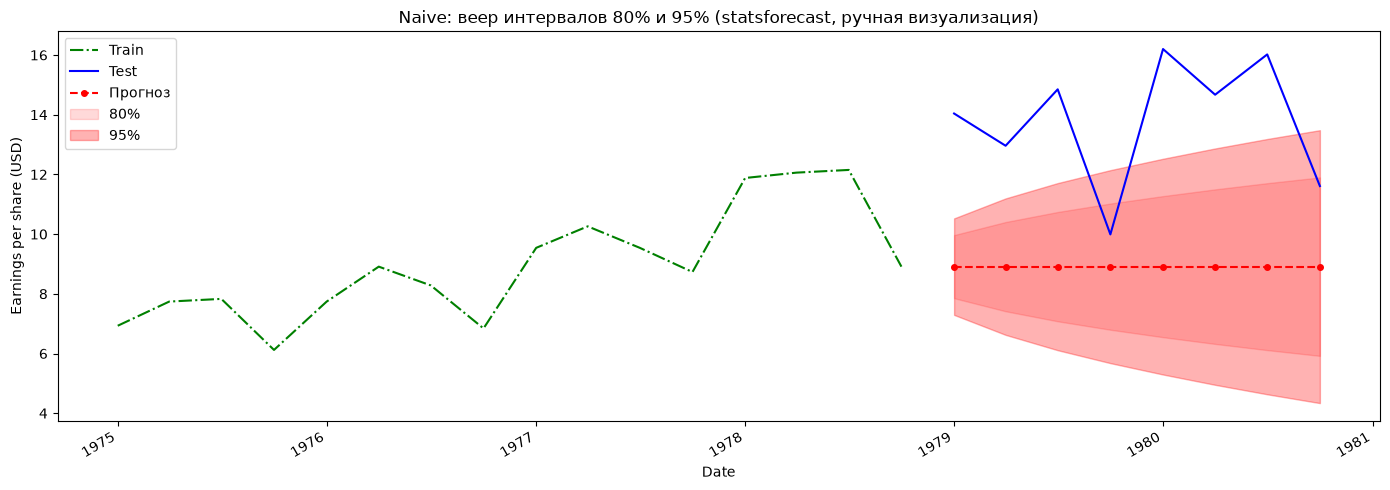

In [23]:
plot_forecast_pi(
    train.iloc[-16:],
    test,
    sf_fc["Naive"].values,
    sf_fc["Naive-lo-95"].values,
    sf_fc["Naive-hi-95"].values,
    "Naive: веер интервалов 80% и 95% (statsforecast, ручная визуализация)",
    lo2=sf_fc["Naive-lo-80"].values,
    hi2=sf_fc["Naive-hi-80"].values,
)

### Встроенная визуализация `statsforecast`

Своя функция удобна, когда нужно контролировать каждую деталь, но у фреймворка есть и готовый
метод: `StatsForecast.plot(df, forecasts_df, models=..., level=...)`. Он сам разбирает имена
колонок `{Model}-lo-{level}` и рисует веер — руками указывать границы не нужно.

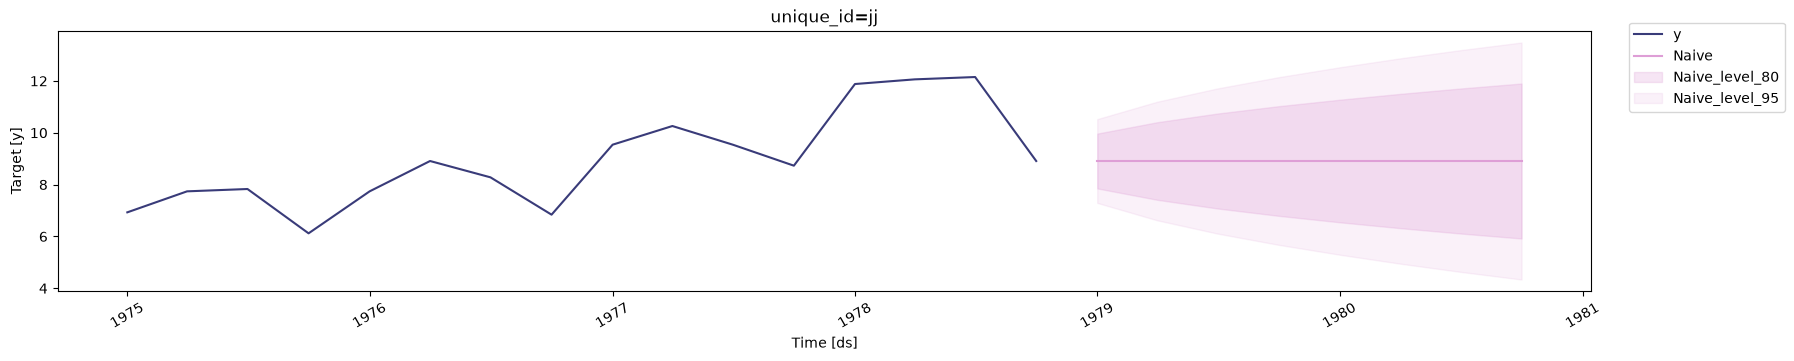

In [49]:
sf.plot(sf_train, sf_fc, models=["Naive"], max_insample_length=16, level=[80, 95], engine="matplotlib")

🔍 `plot` — метод самого объекта `StatsForecast`, а не отдельная функция; тот же график можно
получить из `utilsforecast.plotting.plot_series`, который `statsforecast` и вызывает внутри.
Параметр `max_insample_length` обрезает историю (аналог нашего `train.iloc[-16:]`), а
`engine="plotly"` даёт интерактивную версию. Нарисуем сразу все четыре модели:

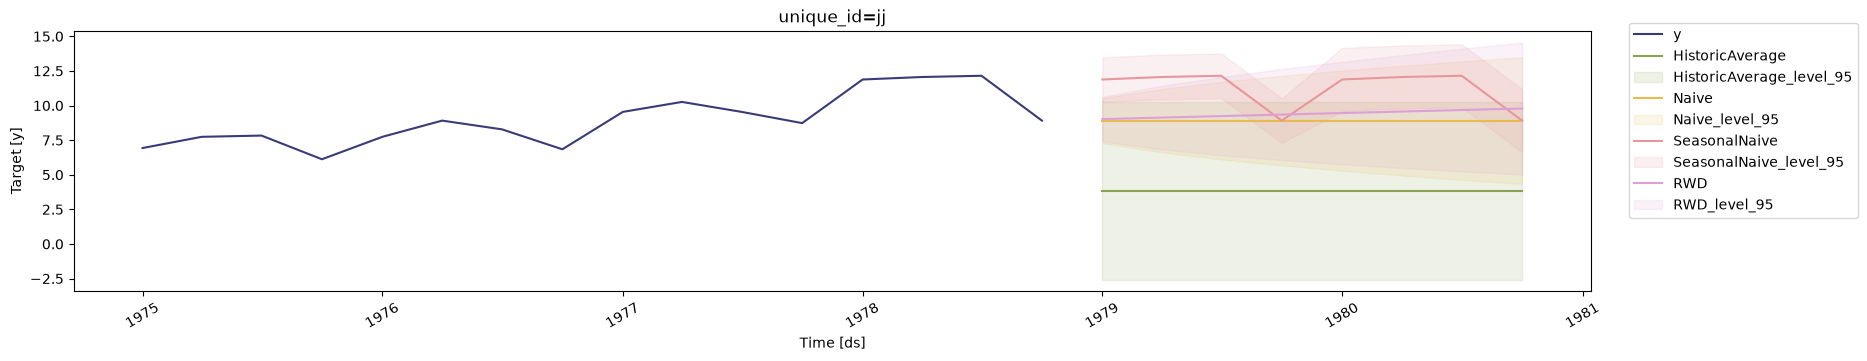

In [50]:
sf.plot(sf_train, sf_fc, models=models, level=[95], max_insample_length=16, engine="matplotlib")

### Метрики через `utilsforecast`

`statsforecast` не считает метрики сам — это работа соседнего пакета `utilsforecast`

Сначала подклеим фактические значения теста к прогнозу 

In [51]:
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import coverage, mqloss, scaled_crps

# from utilsforecast.losses import winkler_score -- в следующем релизе

sf_merged = sf_fc.merge(sf_test[["unique_id", "ds", "y"]], on=["unique_id", "ds"])

metrics_uf = evaluate(sf_merged, metrics=[coverage, mqloss, scaled_crps], models=models, level=[95])
metrics_uf

,unique_id,metric,HistoricAverage,Naive,SeasonalNaive,RWD
0,jj,coverage_level95,0.125000,0.250000,0.250000,0.250000
1,jj,mqloss,1.938067,1.127952,0.425616,0.941187
2,jj,scaled_crps,0.281032,0.163560,0.061717,0.136478


🔍 Главный источник ошибок при первом использовании: `coverage` принимает `models` **списком**
имён моделей и сам достраивает названия колонок `{model}-lo-{level}`/`{model}-hi-{level}`. А
`mqloss` и `scaled_crps`, если вызывать их напрямую (не через `evaluate`), ждут `models` как
**словарь** `{"Naive": ["Naive-lo-95", "Naive-hi-95"]}` плюс массив `quantiles=[0.025, 0.975]` —
`evaluate` берёт эту рутину на себя по параметру `level`, поэтому в учебном коде удобнее вызывать
метрики именно через `evaluate`, а не по отдельности.

Winkler Score в `utilsforecast` пока нет (обещан в следующем релизе), но формат результата
`evaluate` — обычный длинный `DataFrame` со строкой на метрику и колонкой на модель. Значит нашу
ручную реализацию из §3.2 можно просто **дописать строкой в ту же таблицу** — и дальше работать
с одним объектом, а не с метриками врассыпную.

In [52]:
winklers = {
    model: winkler_score(
        sf_test["y"].values, sf_fc[f"{model}-lo-95"].values, sf_fc[f"{model}-hi-95"].values, alpha
    )
    for model in models
}

metrics_uf = pd.concat(
    [metrics_uf, pd.DataFrame([{"unique_id": "jj", "metric": "winkler_score", **winklers}])],
    ignore_index=True,
)
metrics_uf

,unique_id,metric,HistoricAverage,Naive,SeasonalNaive,RWD
0,jj,coverage_level95,0.125000,0.250000,0.250000,0.250000
1,jj,mqloss,1.938067,1.127952,0.425616,0.941187
2,jj,scaled_crps,0.281032,0.163560,0.061717,0.136478
3,jj,winkler_score,155.045399,90.236178,34.049279,75.294927


Для сравнения моделей между собой таблицу удобнее развернуть: строка — модель, колонка — метрика.

In [53]:
sf_table = (
    metrics_uf.drop(columns="unique_id")
    .set_index("metric")
    .T.rename_axis("модель")
    .reset_index()
    .round(3)
)
sf_table

metric,модель,coverage_level95,mqloss,scaled_crps,winkler_score
0,HistoricAverage,0.125,1.938,0.281,155.045
1,Naive,0.250,1.128,0.164,90.236
2,SeasonalNaive,0.250,0.426,0.062,34.049
3,RWD,0.250,0.941,0.136,75.295


## 4.2. `sktime`

У прогнозаторов `sktime` есть не один, а четыре вложенных уровня вероятностного API —
от интервала до полного распределения:

In [54]:
from sktime.forecasting.base import ForecastingHorizon
from sktime.forecasting.naive import NaiveForecaster

y_ser = pd.Series(y)
fh = ForecastingHorizon(hh, is_relative=True)
f_sk = NaiveForecaster(strategy="last", sp=1).fit(y_ser)

pi_sk = f_sk.predict_interval(fh, coverage=0.95)  # 1. интервал: (lower, upper)
q_sk = f_sk.predict_quantiles(fh, alpha=[0.025, 0.975])  # 2. квантили: те же границы, др. язык
var_sk = f_sk.predict_var(fh)  # 3. дисперсия прогноза
proba_sk = f_sk.predict_proba(fh)  # 4. объект-распределение целиком

/Users/a.p.chikov/PycharmProjects/time-series-cu-2026/week_2/.venv/lib/python3.11/site-packages/sktime/forecasting/base/_base.py:1044: UserWarning: Forecasters' predict_proba requires skpro to be present in the python environment, for distribution objects to represent distributional forecasts. To silence this message, ensure skpro is installed in the environment when calling forecasters' predict_proba.
  warn(msg, obj=self, stacklevel=2)


In [55]:
pi_sk.head()

0           
        0.95           
       lower      upper
76  7.293763  10.526237
77  6.624295  11.195705
78  6.110595  11.709405
79  5.677525  12.142475
80  5.295983  12.524017

In [56]:
q_sk.head()

0           
       0.025      0.975
76  7.293763  10.526237
77  6.624295  11.195705
78  6.110595  11.709405
79  5.677525  12.142475
80  5.295983  12.524017

In [57]:
var_sk.head()

,0
76,0.680008
77,1.360016
78,2.040024
79,2.720032
80,3.400041


In [58]:
proba_sk  # Распределение прогнозов

Normal(columns=RangeIndex(start=0, stop=1, step=1),
       index=Index([76, 77, 78, 79, 80, 81, 82, 83], dtype='int64'),
       mu=       0
76  8.91
77  8.91
78  8.91
79  8.91
80  8.91
81  8.91
82  8.91
83  8.91,
       sigma=           0
76  0.824626
77  1.166197
78  1.428294
79  1.649252
80  1.843920
81  2.019913
82  2.181755
83  2.332395)

🔍 Результат — не обычный `DataFrame`, а таблица с **MultiIndex**-колонками: `predict_interval`
возвращает уровни `(имя_переменной, coverage, "lower"/"upper")`, `predict_quantiles` — `(имя,
alpha)`: `pi_sk["lower"]` не сработает, нужно
`pi_sk.iloc[:, 0]` или обращение по полному кортежу `pi_sk[(0, 0.95, "lower")]`. 

Четыре метода
согласованы между собой: `predict_interval` и `predict_quantiles(alpha=[0.025, 0.975])` для
уровня 95% дают одни и те же числа, `predict_var` — их дисперсию, а `predict_proba` — полноценный
объект распределения (в данном случае нормального), из которого первые три и получаются.

In [59]:
lo_sk = pi_sk.iloc[:, 0].values
hi_sk = pi_sk.iloc[:, 1].values

df_intervals = pd.DataFrame(
    {
        "h": hh,
        "Lo95 (руками)": lo.round(3),
        "Lo95 (sktime)": lo_sk.round(3),
        "Hi95 (руками)": hi.round(3),
        "Hi95 (sktime)": hi_sk.round(3),
        "σ_h² (руками)": (sigma_h_naive(sigma_hat, n=n, h=len(hh)) ** 2).round(3),
        "σ_h² (predict_var)": var_sk.iloc[:, 0].values.round(3),
    }
)
df_intervals

,h,Lo95 (руками),Lo95 (sktime),Hi95 (руками),Hi95 (sktime),σ_h² (руками),σ_h² (predict_var)
0,1,7.294,7.294,10.526,10.526,0.68,0.68
1,2,6.624,6.624,11.196,11.196,1.36,1.36
2,3,6.111,6.111,11.709,11.709,2.04,2.04
3,4,5.678,5.678,12.142,12.142,2.72,2.72
4,5,5.296,5.296,12.524,12.524,3.40,3.40
5,6,4.951,4.951,12.869,12.869,4.08,4.08
6,7,4.634,4.634,13.186,13.186,4.76,4.76
7,8,4.339,4.339,13.481,13.481,5.44,5.44


In [60]:
np.testing.assert_allclose(df_intervals["Lo95 (руками)"], df_intervals["Lo95 (sktime)"])
np.testing.assert_allclose(df_intervals["Hi95 (руками)"], df_intervals["Hi95 (sktime)"])
np.testing.assert_allclose(df_intervals["σ_h² (руками)"], df_intervals["σ_h² (predict_var)"])

Границы совпадают почти точно: `NaiveForecaster._predict_var` реализует ту же формулу Table 5.2
из FPP3, что мы вывели руками в разделе 2 (в исходниках `sktime` так и написано — ссылка на
`otexts.com/fpp3/prediction-intervals.html`), только считает $\hat\sigma$ по остаткам fitted-
модели с чуть другой поправкой на степени свободы.

🔍 А что если модель **не умеет** считать интервалы сама? У всех прогнозаторов `sktime` есть флаг
`"capability:pred_int"` в `get_tag(...)`; если он `False`, обернуть модель в
`sktime.forecasting.naive.NaiveVariance(forecaster)` — она посчитает дисперсию прогноза по
остаткам k-fold бэктеста и добавит те же четыре метода `predict_*`. Тот же принцип «наивная
оценка дисперсии по бэктесту» мы увидим дальше у `etna`.

### Встроенная визуализация `sktime`

У `sktime` есть `sktime.utils.plotting.plot_series`, которая принимает интервал в том самом
формате с MultiIndex, что вернул `predict_interval` — перекладывать колонки руками не нужно.

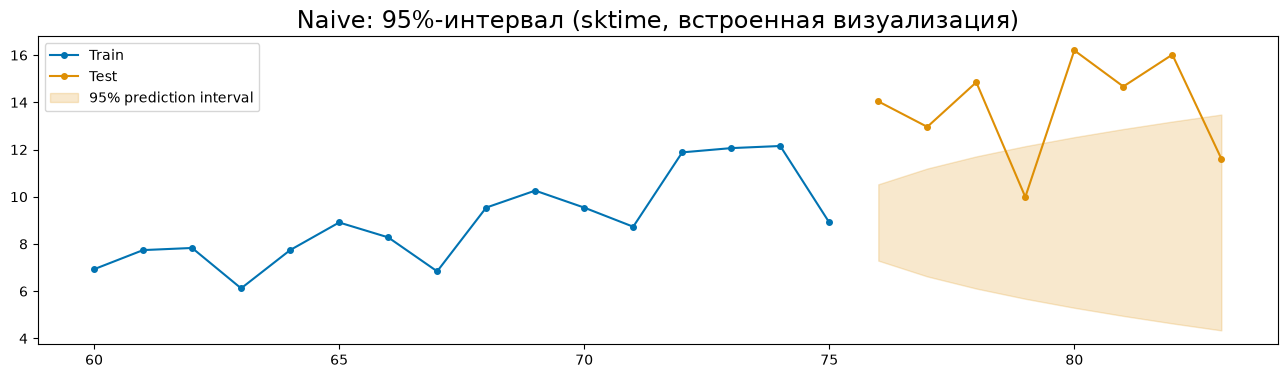

In [61]:
from sktime.utils.plotting import plot_series

y_true_ser = pd.Series(y_true, index=pd.RangeIndex(n, n + h))

plot_series(
    y_ser.iloc[-16:],
    y_true_ser,
    labels=["Train", "Test"],
    pred_interval=pi_sk,
    title="Naive: 95%-интервал (sktime, встроенная визуализация)",
)
plt.show()

🔍 По оси X здесь номера наблюдений, а не даты: мы отдали `sktime` обычный `pd.Series` с
`RangeIndex`. Если передать ряд с `PeriodIndex`/`DatetimeIndex`, подписи станут датами — но
`sktime` требует регулярный индекс с заданной частотой, поэтому для квартального ряда пришлось бы
делать `pd.PeriodIndex(train["date"], freq="Q")`.

### Метрики через `sktime.performance_metrics.forecasting.probabilistic`

Соберём сразу **все четыре базовых метода**: у `NaiveForecaster` за них отвечают параметры
`strategy` (`"mean"`, `"last"`, `"drift"`) и `sp` (длина сезона).

In [62]:
from sktime.performance_metrics.forecasting.probabilistic import (
    CRPS,
    EmpiricalCoverage,
    IntervalWidth,
    PinballLoss,
)

sk_models = {
    "Mean": NaiveForecaster(strategy="mean", sp=1),
    "Naive": NaiveForecaster(strategy="last", sp=1),
    "SeasonalNaive": NaiveForecaster(strategy="last", sp=m),
    "Drift": NaiveForecaster(strategy="drift"),
}

pl, ec, iw, crps_sk = PinballLoss(), EmpiricalCoverage(), IntervalWidth(), CRPS()

rows = []
for name, forecaster in sk_models.items():
    forecaster = forecaster.fit(y_ser)
    pi_m = forecaster.predict_interval(fh, coverage=0.95)
    q_m = forecaster.predict_quantiles(fh, alpha=[0.025, 0.975])
    proba_m = forecaster.predict_proba(fh)
    rows.append(
        {
            "модель": name,
            "EmpiricalCoverage": ec(y_true_ser, pi_m),
            "IntervalWidth": iw(y_true_ser, pi_m),
            "PinballLoss": pl(y_true_ser, q_m),
            "CRPS": crps_sk(y_true_ser, proba_m),
            # Winkler в sktime нет — берём свою реализацию из §3.2
            "Winkler": winkler_score(y_true, pi_m.iloc[:, 0].values, pi_m.iloc[:, 1].values, alpha),
        }
    )

sk_table = pd.DataFrame(rows).round(3)
sk_table

/Users/a.p.chikov/PycharmProjects/time-series-cu-2026/week_2/.venv/lib/python3.11/site-packages/sktime/forecasting/base/_base.py:1044: UserWarning: Forecasters' predict_proba requires skpro to be present in the python environment, for distribution objects to represent distributional forecasts. To silence this message, ensure skpro is installed in the environment when calling forecasters' predict_proba.
  warn(msg, obj=self, stacklevel=2)
/Users/a.p.chikov/PycharmProjects/time-series-cu-2026/week_2/.venv/lib/python3.11/site-packages/sktime/forecasting/base/_base.py:1044: UserWarning: Forecasters' predict_proba requires skpro to be present in the python environment, for distribution objects to represent distributional forecasts. To silence this message, ensure skpro is installed in the environment when calling forecasters' predict_proba.
  warn(msg, obj=self, stacklevel=2)
/Users/a.p.chikov/PycharmProjects/time-series-cu-2026/week_2/.venv/lib/python3.11/site-packages/sktime/forecasting/b

,модель,EmpiricalCoverage,IntervalWidth,PinballLoss,CRPS,Winkler
0,Mean,0.125,12.754,1.956,8.116,156.444
1,Naive,0.250,6.589,1.128,4.034,90.236
2,SeasonalNaive,0.250,3.887,0.426,2.009,34.049
3,Drift,0.250,6.796,0.934,3.595,74.702


In [64]:
sf_table

metric,модель,coverage_level95,mqloss,scaled_crps,winkler_score
0,HistoricAverage,0.125,1.938,0.281,155.045
1,Naive,0.250,1.128,0.164,90.236
2,SeasonalNaive,0.250,0.426,0.062,34.049
3,RWD,0.250,0.941,0.136,75.295


🔍 Обратите внимание, что каждая метрика ест свой формат: `EmpiricalCoverage`/`IntervalWidth` —
результат `predict_interval`, `PinballLoss` — результат `predict_quantiles`, а `CRPS` — объект
распределения из `predict_proba` (то самое $\mathcal N(\hat y_h,\sigma_h^2)$ из §3.4). Перепутать
их местами — самая частая ошибка: метрика упадёт на проверке формата колонок.

`sktime` умеет считать такие метрики и в кросс-валидации через
`sktime.forecasting.model_evaluation.evaluate(forecaster=..., cv=..., scoring=PinballLoss())` —
с этим вы встретитесь на занятии про валидацию.

## 4.3. `etna`

У `etna` нет отдельного «режима с интервалом» внутри модели — вместо этого весь **пайплайн**
оборачивается в объект из `etna.prediction_intervals`, который умеет считать неопределённость
для любой модели снизу.

In [40]:
from etna.datasets import TSDataset
from etna.metrics import Coverage as EtnaCoverage
from etna.metrics import Width as EtnaWidth
from etna.models import NaiveModel
from etna.pipeline import Pipeline
from etna.prediction_intervals import NaiveVariancePredictionIntervals

etna_long = df.rename(columns={"date": "timestamp", "data": "target"})
etna_long["segment"] = "jj"

ts = TSDataset(
    TSDataset.to_dataset(etna_long), freq="QS-OCT"
)  # метка квартала у pandas не совпадает с "QS", но месяцы те же
train_ts, test_ts = ts.train_test_split(test_size=h)

pipeline = Pipeline(model=NaiveModel(lag=1), horizon=h)
pipeline = NaiveVariancePredictionIntervals(pipeline=pipeline)
pipeline.fit(train_ts)

etna_forecast = pipeline.forecast(prediction_interval=True, quantiles=(0.025, 0.975), n_folds=3)
etna_forecast.to_pandas()

/Users/a.p.chikov/PycharmProjects/time-series-cu-2026/week_2/.venv/lib/python3.11/site-packages/etna/settings.py:35: UserWarning: etna[torch] is not available, to install it, run `pip install etna[torch]`
  warnings.warn("etna[torch] is not available, to install it, run `pip install etna[torch]`")
/Users/a.p.chikov/PycharmProjects/time-series-cu-2026/week_2/.venv/lib/python3.11/site-packages/etna/settings.py:49: UserWarning: etna[chronos] is not available, to install it, run `pip install etna[chronos]`
  warnings.warn("etna[chronos] is not available, to install it, run `pip install etna[chronos]`")
/Users/a.p.chikov/PycharmProjects/time-series-cu-2026/week_2/.venv/lib/python3.11/site-packages/etna/settings.py:64: UserWarning: etna[timesfm] is not available, to install it, run `pip install etna[timesfm]`
  warnings.warn("etna[timesfm] is not available, to install it, run `pip install etna[timesfm]`")
/Users/a.p.chikov/PycharmProjects/time-series-cu-2026/week_2/.venv/lib/python3.11/site-

segment        jj                          
feature    target target_0.025 target_0.975
timestamp                                  
1979-01-01   8.91     5.374723    12.445277
1979-04-01   8.91     4.166928    13.653072
1979-07-01   8.91     5.054745    12.765255
1979-10-01   8.91     5.919915    11.900085
1980-01-01   8.91     3.139911    14.680089
1980-04-01   8.91     1.731714    16.088286
1980-07-01   8.91     0.804702    17.015298
1980-10-01   8.91     2.796891    15.023109

segment        jj                          
feature    target target_0.025 target_0.975
timestamp                                  
1979-01-01   8.91     5.374723    12.445277
1979-04-01   8.91     4.166928    13.653072
1979-07-01   8.91     5.054745    12.765255
1979-10-01   8.91     5.919915    11.900085
1980-01-01   8.91     3.139911    14.680089
1980-04-01   8.91     1.731714    16.088286
1980-07-01   8.91     0.804702    17.015298
1980-10-01   8.91     2.796891    15.023109

🔍 Ключевое отличие от `statsforecast`/`sktime`: у `NaiveVariancePredictionIntervals` **нет**
аналитической формулы Table 5.2. Внутри она делает k-fold бэктест (`n_folds` окон), на каждом
окне считает остатки модели на весь горизонт, оценивает дисперсию по этой матрице остатков и
только затем строит нормальный квантиль вокруг неё (`prediction_intervals/naive_variance.py`).
Поэтому границы `etna` **не обязаны** совпадать с ручными — это принципиально другой источник
оценки $\hat\sigma_h$, эмпирический, а не формульный. У такого подхода есть цена: на коротких
рядах не хватит наблюдений на `n_folds` окон бэктеста нужной длины горизонта — тогда `n_folds`
приходится уменьшать.

### Встроенная визуализация `etna`

В `etna.analysis` есть `plot_forecast`, которая рисует train/test/прогноз и — по флагу
`prediction_intervals=True` — закрашенную полосу по нужным квантилям.

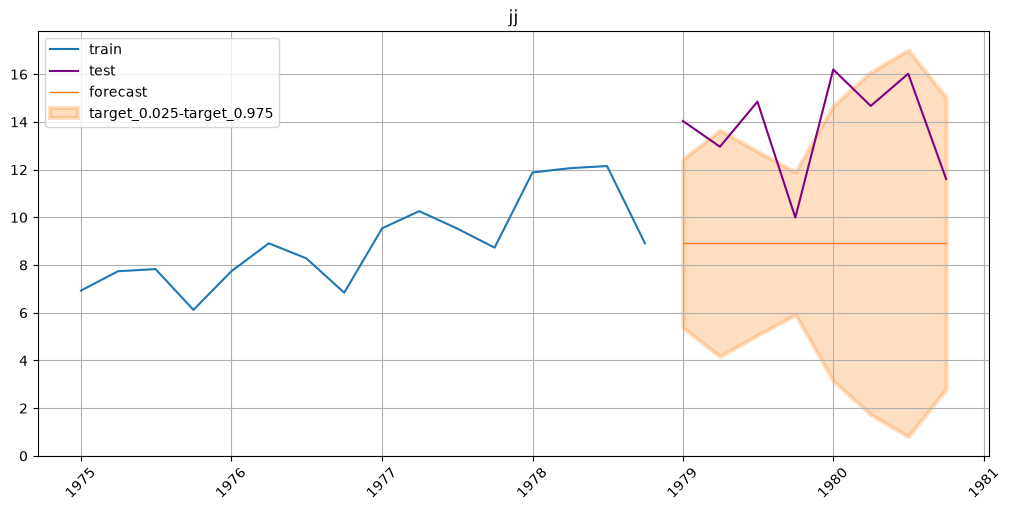

In [41]:
from etna.analysis import plot_forecast

plot_forecast(
    forecast_ts=etna_forecast,
    test_ts=test_ts,
    train_ts=train_ts,
    n_train_samples=16,
    prediction_intervals=True,
    quantiles=[0.025, 0.975],
)

### Метрики и сравнение четырёх моделей

Метрики `Coverage`/`Width` берут имена колонок с границами прямо из объекта прогноза:

In [42]:
lower_name, upper_name = etna_forecast.prediction_intervals_names
etna_cov = EtnaCoverage(lower_name=lower_name, upper_name=upper_name)(test_ts, etna_forecast)
etna_width = EtnaWidth(lower_name=lower_name, upper_name=upper_name)(test_ts, etna_forecast)
print(f"Coverage (etna): {etna_cov['jj']:.1%}")
print(f"Width (etna):    {etna_width['jj']:.2f}")

Coverage (etna): 62.5%
Width (etna):    10.57


Соберём таблицу по четырём методам — как для `statsforecast` и `sktime`. Полного набора базовых
моделей в `etna` нет, поэтому подбираем ближайшие аналоги:

| метод | в `etna` | комментарий |
|---|---|---|
| Mean | `MovingAverageModel(window=40)` | скользящее среднее; окно во всю историю взять нельзя — в бэктесте на коротких фолдах не хватит контекста |
| Naive | `NaiveModel(lag=1)` | точный аналог |
| Seasonal naive | `SeasonalMovingAverageModel(window=1, seasonality=4)` | среднее по одному прошлому сезону = seasonal naive |
| Drift | `HoltModel()` | прямого аналога RandomWalkWithDrift нет; берём ближайшую модель с линейным трендом |

In [43]:
from etna.models import HoltModel, MovingAverageModel, SeasonalMovingAverageModel

etna_models = {
    "Mean (MA-40)": MovingAverageModel(window=40),
    "Naive": NaiveModel(lag=1),
    "SeasonalNaive": SeasonalMovingAverageModel(window=1, seasonality=m),
    "Holt (≈Drift)": HoltModel(),
}

rows = []
for name, model in etna_models.items():
    pipe = NaiveVariancePredictionIntervals(pipeline=Pipeline(model=model, horizon=h))
    pipe.fit(train_ts)
    fc = pipe.forecast(prediction_interval=True, quantiles=(0.025, 0.975), n_folds=3)

    ln, un = fc.prediction_intervals_names
    lo_e = fc.to_pandas()[("jj", ln)].values
    hi_e = fc.to_pandas()[("jj", un)].values
    rows.append(
        {
            "модель": name,
            "Coverage": EtnaCoverage(lower_name=ln, upper_name=un)(test_ts, fc)["jj"],
            "Width": EtnaWidth(lower_name=ln, upper_name=un)(test_ts, fc)["jj"],
            # Winkler/CRPS в etna.metrics нет — считаем своей функцией из §3.2
            "Winkler": winkler_score(y_true, lo_e, hi_e, alpha),
        }
    )

etna_table = pd.DataFrame(rows).round(3)
etna_table

[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.

,модель,Coverage,Width,Winkler
0,Mean (MA-40),0.875,21.525,21.763
1,Naive,0.625,10.573,36.570
2,SeasonalNaive,1.000,9.184,9.184
3,Holt (≈Drift),0.500,6.448,14.867


🔍 Числа заметно отличаются от `statsforecast`/`sktime` — и это ожидаемо: дисперсия здесь
оценена по остаткам трёх окон бэктеста, а не по формуле. Покрытие в среднем **выше**, а
интервалы шире: эмпирическая оценка «видит» реальные многошаговые промахи модели, тогда как
аналитическая формула их недооценивает (ровно та систематическая узость, о которой мы говорили
в §1.2). Цена — шумность: три окна на 76 точках дают очень грубую оценку $\sigma_h$.

Кроме `NaiveVariancePredictionIntervals`, в `etna.prediction_intervals` есть ещё
`EmpiricalPredictionIntervals` (квантили самих остатков, без нормального допущения) и
`ConformalPredictionIntervals` — к ним мы вернёмся в разделе 5.

## 4.4. Сводное сравнение: методы × фреймворки

Теперь у нас есть три таблицы одного формата — по четырём методам в каждой. Сначала «ручная»
сводка по границам `statsforecast` (те же Coverage / MIW / Winkler, что мы писали в разделе 3),
а затем — сравнение трёх фреймворков между собой.

In [44]:
def row(name, lo_, hi_):
    return {
        "метод": name,
        "Coverage (цель 95%)": f"{coverage_rate(sf_test['y'].values, lo_, hi_):.1%}",
        "MIW": round(mean_interval_width(lo_, hi_), 2),
        "Winkler": round(winkler_score(sf_test["y"].values, lo_, hi_, alpha), 2),
    }


pd.DataFrame([row(m_, sf_fc[f"{m_}-lo-95"].values, sf_fc[f"{m_}-hi-95"].values) for m_ in models])

,метод,Coverage (цель 95%),MIW,Winkler
0,HistoricAverage,12.5%,12.84,155.05
1,Naive,25.0%,6.59,90.24
2,SeasonalNaive,25.0%,3.89,34.05
3,RWD,25.0%,6.75,75.29


А вот главное сравнение: одни и те же четыре метода, один и тот же тест, три разных фреймворка.
Приводим их таблицы к общим именам колонок и склеиваем.

In [45]:
common = ["framework", "метод", "Coverage", "Width", "Winkler"]

sf_part = sf_table.assign(framework="statsforecast").rename(
    columns={"coverage_level95": "Coverage", "winkler_score": "Winkler", "модель": "метод"}
)
sf_part["Width"] = [
    mean_interval_width(sf_fc[f"{m_}-lo-95"].values, sf_fc[f"{m_}-hi-95"].values) for m_ in models
]

sk_part = sk_table.assign(framework="sktime").rename(
    columns={"EmpiricalCoverage": "Coverage", "IntervalWidth": "Width", "модель": "метод"}
)
etna_part = etna_table.assign(framework="etna").rename(columns={"модель": "метод"})

comparison = pd.concat([sf_part[common], sk_part[common], etna_part[common]], ignore_index=True)
comparison.round(3)

,framework,метод,Coverage,Width,Winkler
0,statsforecast,HistoricAverage,0.125,12.839,155.045
1,statsforecast,Naive,0.250,6.589,90.236
2,statsforecast,SeasonalNaive,0.250,3.887,34.049
3,statsforecast,RWD,0.250,6.750,75.295
4,sktime,Mean,0.125,12.754,156.444
5,sktime,Naive,0.250,6.589,90.236
6,sktime,SeasonalNaive,0.250,3.887,34.049
7,sktime,Drift,0.250,6.796,74.702
8,etna,Mean (MA-40),0.875,21.525,21.763
9,etna,Naive,0.625,10.573,36.570


Что видно в этой таблице:

- `statsforecast` и `sktime` для **одинаковых** методов дают практически одинаковые числа — обе
  библиотеки считают ту же аналитическую формулу Table 5.2, расхождения только в поправке на
  степени свободы при оценке $\hat\sigma$;
- `etna` стоит особняком: покрытие выше, интервалы шире — потому что $\sigma_h$ там оценивается
  эмпирически по бэктесту (плюс сами модели — не точные аналоги, см. §4.3);
- метрик, общих для всех трёх, немного: Coverage и Width есть везде, CRPS — только в `sktime`
  (и как `scaled_crps` в `utilsforecast`), а Winkler во всех трёх пришлось считать своей
  функцией. Это типичная ситуация: **ручная реализация метрики нужна не вместо фреймворка, а
  чтобы сводить его результаты с остальными.**

Здесь наглядно виден компромисс **покрытие ↔ ширина**: метод может достигать нужного покрытия
только за счёт более широких (и потому менее информативных) интервалов, и Winkler Score
штрафует за оба перекоса сразу. 🔍 Восемь точек теста — это всё ещё очень шумная оценка Coverage
Rate (шаг $12.5\%$): один провал или один случайный успех сильно двигает число. Честная проверка
интервалов делается на нескольких окнах кросс-валидации, а не на одном тесте — этим мы займёмся
на Семинаре 2, когда будем разбирать схемы валидации для временных рядов.

---
# 5. А что дальше: бутстреп и конформное прогнозирование

Нормальные формулы опираются на предположение о том, что остатки независимы и нормально
распределены — как мы видели в разделе 1, для J&J это предположение выполняется не идеально.
Есть два способа строить PI, не полагаясь на нормальность:

- **Бутстреп** — насэмплировать множество будущих траекторий из исторических остатков и взять
  эмпирические квантили на каждом шаге горизонта;
- **Конформное прогнозирование** — откалибровать ширину интервала по ошибкам модели на
  нескольких прошлых окнах, с формальной гарантией покрытия при минимальных предположениях.

Разберём их подробно на отдельном занятии

---
# Выводы

- **Интервал прогноза** сообщает неопределённость точечного прогноза; при нормальных остатках
  он равен $\hat y_{n+h}\pm z_{1-\alpha/2}\,\hat\sigma_h$, где $\hat\sigma_1$ оценивается по
  остаткам одношагового прогноза.
- Для базовых методов известны **аналитические формулы** дисперсии (FPP3, Table 5.2). Они не
  постулируются, а **выводятся** из четырёх предположений о шуме (нулевое среднее,
  некоррелированность, постоянная дисперсия, нормальность): ошибка $h$-шагового прогноза — это
  сумма будущих шоков, её дисперсия складывается, отсюда $\sqrt h$ у naive; у drift добавляется
  ошибка оценки наклона, дающая член $h^2/(n-1)$. Интервал закономерно **расширяется с
  горизонтом** — быстрее всего у drift и naive, почти не растёт у mean.
- Качество интервалов измеряют специальными метриками: **Coverage Rate** и **Mean Interval
  Width** (компромисс покрытие↔ширина), **Winkler Score** (ширина + штраф за промахи),
  **Quantile Score / MQLoss** (асимметричный штраф, минимум которого — честный квантиль) и
  **CRPS** (та же pinball loss, усреднённая по всем уровням, то есть всё распределение целиком;
  для базовых моделей это распределение — то самое $\mathcal N(\hat y_h, \sigma_h^2)$ из §2).
- `statsforecast`, `sktime` и `etna` дают интервалы и метрики через разные интерфейсы, но
  `statsforecast` и `sktime` под капотом считают одну и ту же аналитическую формулу, а `etna`
  всегда оценивает дисперсию эмпирически, по бэктесту — поэтому её границы не обязаны совпадать
  с ручными.
- Реальные интервалы почти всегда **слишком узкие**, потому что формула не учитывает
  неопределённость в параметрах и в выборе модели. Всегда проверяйте покрытие на отложенных
  данных — и лучше на нескольких окнах кросс-валидации, а не на одном тесте.
- Если остатки не нормальны или ряд нестационарен — на помощь приходят бутстреп и конформное
  прогнозирование; разберём их на отдельном занятии.